# Threshold Target Evaluation

Explore whether a thresholded target (up / no-move / down) reduces
the "many tiny moves" problem relative to continuous regression.

In [79]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.io import load_dataset_with_meta
from src.analysis.market_context import attach_segment_id, label_profile
from src.analysis.baseline_eval import (
    full_utc_days, split_by_utc_days, bucket_analysis, tail_stats,
)
from src.dataset.schema import FEATURE_COLUMNS, LABEL_COL

pd.set_option("display.float_format", "{:.6f}".format)
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

## Configuration

In [80]:
DS_DIR = Path("../data/datasets/binance/BTCUSDT_v2")

HORIZONS = {
    500:  DS_DIR / "dataset_d4D_i100_tw1000_w600_h500.parquet",
    1000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h1000.parquet",
    2000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h2000.parquet",
    5000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h5000.parquet",
    10000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h10000.parquet",
}

REF_PRICE = 69_492.49
TICK_SIZE = 0.01

# Thresholds in ticks to define up/no-move/down
THRESHOLDS_TICKS = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

TRAIN_DAYS = 1
VAL_DAYS = 1
TEST_DAYS = 1

## Load & split

In [81]:
def load_and_split(horizon_ms_key):
    df, meta = load_dataset_with_meta(HORIZONS[horizon_ms_key])
    attach_segment_id(df, int(meta["interval_ms"]))
    h = int(meta["horizon_ms"])
    days = full_utc_days(df)
    need = TRAIN_DAYS + VAL_DAYS + TEST_DAYS
    print(f"h={h}ms — full UTC days: {days}  (need {need})")
    assert len(days) >= need
    t = days[:TRAIN_DAYS]
    v = days[TRAIN_DAYS:TRAIN_DAYS + VAL_DAYS]
    s = days[TRAIN_DAYS + VAL_DAYS:TRAIN_DAYS + VAL_DAYS + TEST_DAYS]
    parts = split_by_utc_days(df, t, v, s, h)
    return parts, h


# Load all horizons
data = {}  # h_ms -> {"parts": ..., "h": ...}
for h_ms in HORIZONS:
    parts, h = load_and_split(h_ms)
    data[h_ms] = {"parts": parts, "h": h}
    print()

h=500ms — full UTC days: [datetime.date(2026, 3, 24), datetime.date(2026, 3, 25), datetime.date(2026, 3, 26)]  (need 3)
  Purged 5 rows from train tail
  Purged 5 rows from val tail
train:    835,177 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:59.400000+00:00]
  val:    845,059 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:59.400000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]

h=1000ms — full UTC days: [datetime.date(2026, 3, 24), datetime.date(2026, 3, 25), datetime.date(2026, 3, 26)]  (need 3)
  Purged 10 rows from train tail
  Purged 10 rows from val tail
train:    835,157 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:58.900000+00:00]
  val:    845,039 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:58.900000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]

h=2000ms — full UTC days: [datetime.date(2026, 3, 24), datetime.date(2026, 3, 25), datetime.date(2026, 3, 26)

## Threshold target construction

For each threshold T (in ticks):
- `up`   = label > T * tick_size
- `down` = label < -T * tick_size
- `no_move` = otherwise

In [82]:
def make_class_target(label: np.ndarray, threshold_ticks: int) -> np.ndarray:
    """Return array of -1 (down), 0 (no_move), +1 (up)."""
    thr = threshold_ticks * TICK_SIZE
    return np.where(label > thr, 1, np.where(label < -thr, -1, 0))


def class_balance(y: np.ndarray) -> pd.Series:
    total = len(y)
    return pd.Series({
        "down": (y == -1).sum() / total,
        "no_move": (y == 0).sum() / total,
        "up": (y == 1).sum() / total,
    })

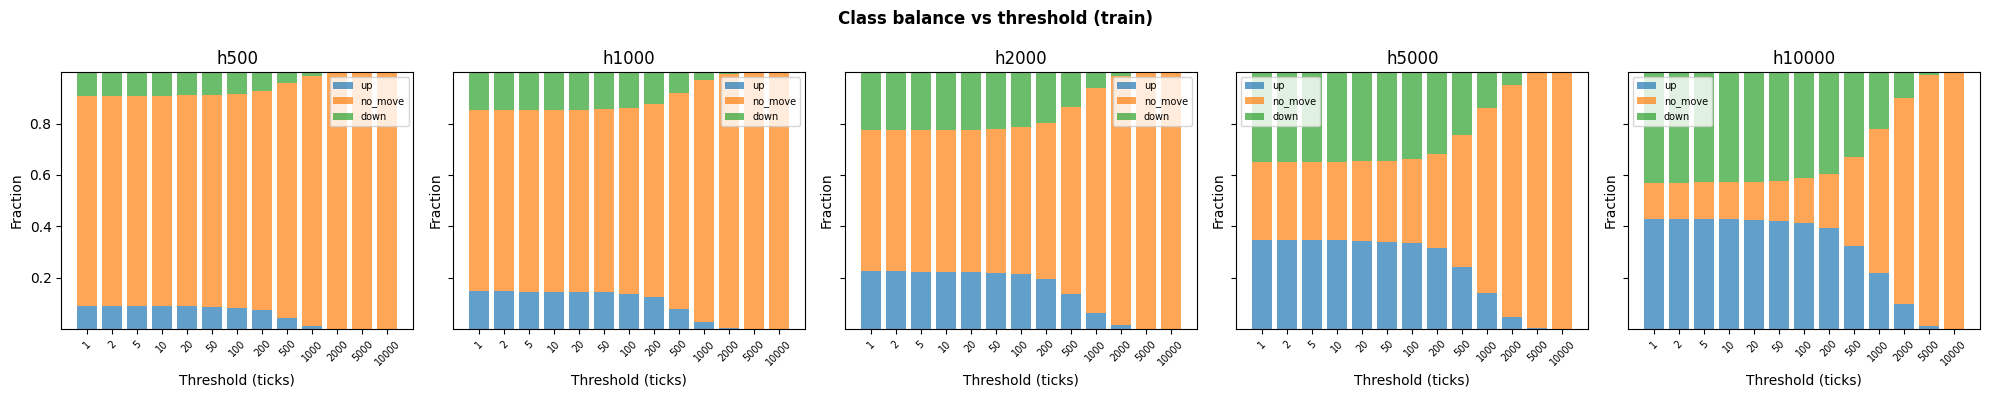

In [83]:
# Class balance for each horizon and threshold
rows = []
for h_ms, d in data.items():
    label = d["parts"]["train"][LABEL_COL].values
    for thr in THRESHOLDS_TICKS:
        y = make_class_target(label, thr)
        bal = class_balance(y)
        rows.append({"horizon": f"h{h_ms}", "threshold_ticks": thr, **bal.to_dict()})

balance_df = pd.DataFrame(rows)

# Plot: stacked bar per horizon
n_h = len(data)
fig, axes = plt.subplots(1, n_h, figsize=(4 * n_h, 4), sharey=True)
if n_h == 1:
    axes = [axes]

for ax, h_ms in zip(axes, data):
    sub = balance_df[balance_df["horizon"] == f"h{h_ms}"].reset_index(drop=True)
    x = np.arange(len(sub))
    ax.bar(x, sub["up"], label="up", alpha=0.7)
    ax.bar(x, sub["no_move"], bottom=sub["up"], label="no_move", alpha=0.7)
    ax.bar(x, sub["down"], bottom=sub["up"] + sub["no_move"], label="down", alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["threshold_ticks"].astype(str), rotation=45, fontsize=7)
    ax.set_xlabel("Threshold (ticks)")
    ax.set_ylabel("Fraction")
    ax.set_title(f"h{h_ms}")
    ax.legend(fontsize=7)

fig.suptitle("Class balance vs threshold (train)", fontweight="bold")
fig.tight_layout()
plt.show()

## Simple baseline: sign of feature as directional prediction

For each feature score, compute classification accuracy and conditional
mean label in the "up" and "down" predicted classes.

In [84]:
def sign_baseline_eval(score, label, class_target):
    """Evaluate sign(score) as a directional predictor against class_target."""
    pred = np.sign(score)  # -1, 0, +1
    # Accuracy on non-zero predictions vs non-zero targets
    mask = (pred != 0) & (class_target != 0)
    acc = (pred[mask] == class_target[mask]).mean() if mask.sum() > 0 else np.nan

    # Conditional mean label on non-trivial moves only
    long_mask = (pred > 0) & (class_target != 0)
    short_mask = (pred < 0) & (class_target != 0)
    long_mean = label[long_mask].mean() if long_mask.sum() > 0 else np.nan
    short_mean = label[short_mask].mean() if short_mask.sum() > 0 else np.nan

    return {
        "dir_accuracy": acc,
        "long_mean_bps": long_mean / REF_PRICE * 1e4,
        "short_mean_bps": -short_mean / REF_PRICE * 1e4,
        "coverage": mask.sum() / len(score),
    }

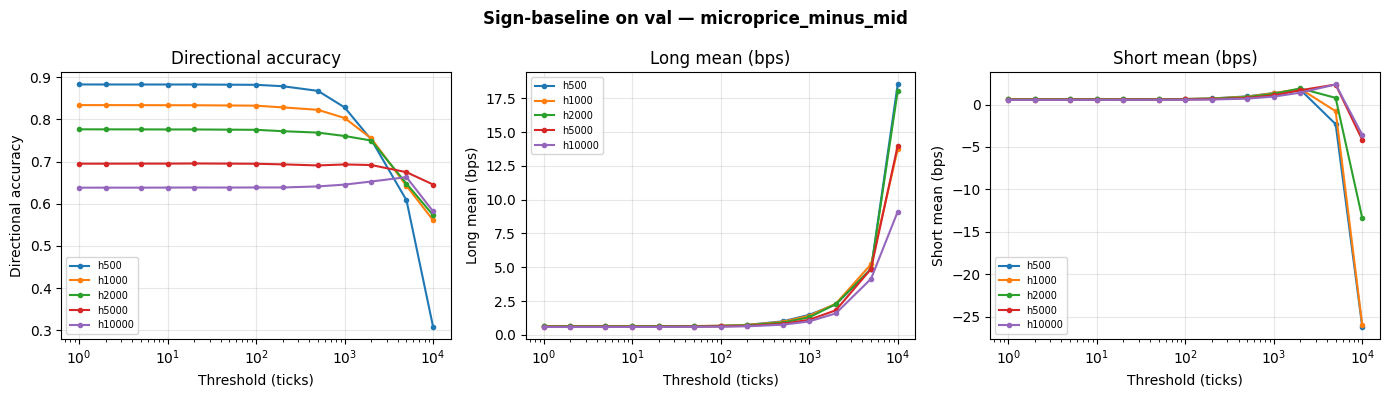

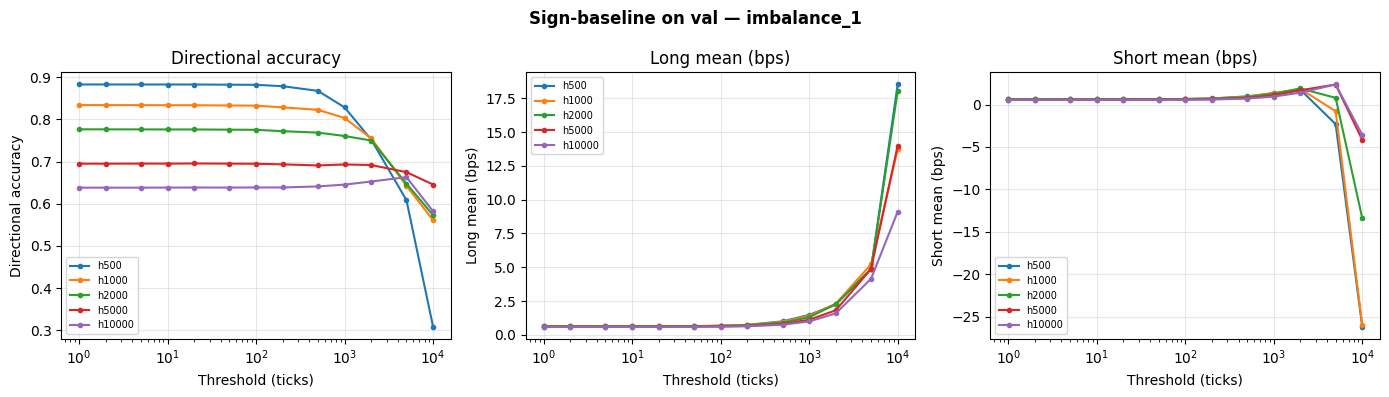

In [85]:
FEATURES_TO_TEST = ["microprice_minus_mid", "imbalance_1"]

rows = []
for h_ms, d in data.items():
    val = d["parts"]["val"]
    label = val[LABEL_COL].values
    for thr in THRESHOLDS_TICKS:
        ct = make_class_target(label, thr)
        for feat in FEATURES_TO_TEST:
            score = val[feat].values
            res = sign_baseline_eval(score, label, ct)
            rows.append({
                "horizon": f"h{h_ms}",
                "threshold_ticks": thr,
                "feature": feat,
                **res,
            })

sign_df = pd.DataFrame(rows)

# Plot directional accuracy and conditional mean bps
metrics = ["dir_accuracy", "long_mean_bps", "short_mean_bps"]
titles = ["Directional accuracy", "Long mean (bps)", "Short mean (bps)"]

for feat in FEATURES_TO_TEST:
    sub = sign_df[sign_df["feature"] == feat]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric, title in zip(axes, metrics, titles):
        for h_ms in data:
            h_sub = sub[sub["horizon"] == f"h{h_ms}"]
            ax.plot(h_sub["threshold_ticks"], h_sub[metric], marker="o", markersize=3, label=f"h{h_ms}")
        ax.set_xscale("log")
        ax.set_xlabel("Threshold (ticks)")
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"Sign-baseline on val — {feat}", fontweight="bold")
    fig.tight_layout()
    plt.show()

## Conditional analysis: mean label given predicted direction, by threshold

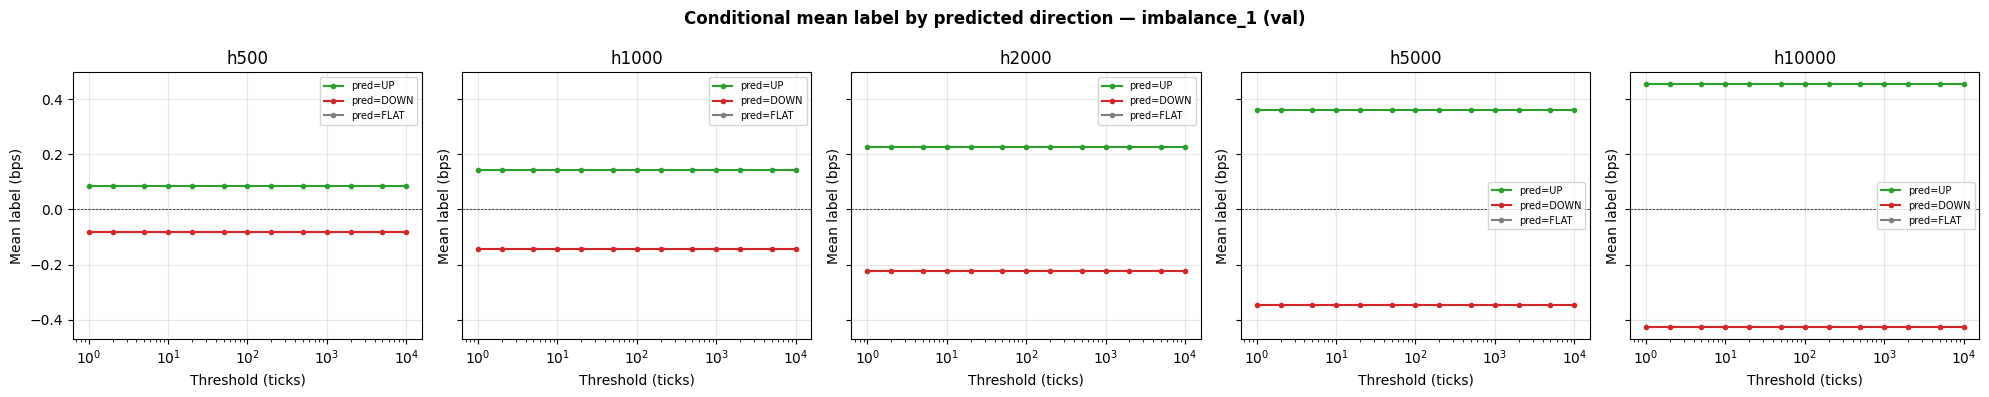

In [86]:
# Conditional mean label (bps) given predicted direction, by threshold — imbalance_1
fig, axes = plt.subplots(1, len(data), figsize=(4 * len(data), 4), sharey=True)
if len(data) == 1:
    axes = [axes]

for ax, (h_ms, d) in zip(axes, data.items()):
    val = d["parts"]["val"]
    label = val[LABEL_COL].values
    score = val["imbalance_1"].values
    pred = np.sign(score)

    means = {"UP": [], "DOWN": [], "FLAT": []}
    for thr in THRESHOLDS_TICKS:
        ct = make_class_target(label, thr)
        for pred_val, name in [(1, "UP"), (-1, "DOWN"), (0, "FLAT")]:
            mask = pred == pred_val
            means[name].append(label[mask].mean() / REF_PRICE * 1e4 if mask.sum() > 0 else np.nan)

    for name, color in [("UP", "tab:green"), ("DOWN", "tab:red"), ("FLAT", "tab:gray")]:
        ax.plot(THRESHOLDS_TICKS, means[name], marker="o", markersize=3, label=f"pred={name}", color=color)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("Threshold (ticks)")
    ax.set_ylabel("Mean label (bps)")
    ax.set_title(f"h{h_ms}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("Conditional mean label by predicted direction — imbalance_1 (val)", fontweight="bold")
fig.tight_layout()
plt.show()

## No-move fraction vs threshold

How does the fraction of "no-move" observations change with threshold?

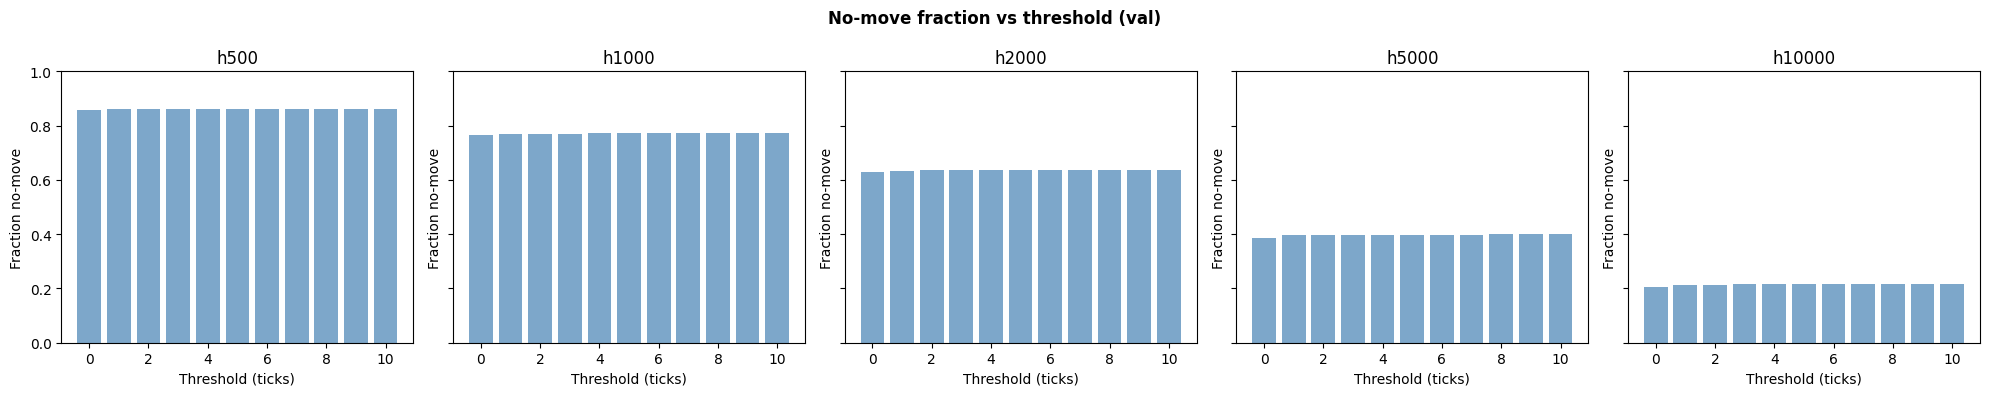

In [87]:
n_h = len(data)
fig, axes = plt.subplots(1, n_h, figsize=(4 * n_h, 4), sharey=True)
if n_h == 1:
    axes = [axes]
tick_range = np.arange(0, 11)

for ax, (h_ms, d) in zip(axes, data.items()):
    label = d["parts"]["val"][LABEL_COL].values
    no_move_frac = []
    for t in tick_range:
        ct = make_class_target(label, t)
        no_move_frac.append((ct == 0).mean())
    ax.bar(tick_range, no_move_frac, color="steelblue", alpha=0.7)
    ax.set_xlabel("Threshold (ticks)")
    ax.set_ylabel("Fraction no-move")
    ax.set_title(f"h{h_ms}")
    ax.set_ylim(0, 1)

fig.suptitle("No-move fraction vs threshold (val)", fontweight="bold")
fig.tight_layout()
plt.show()

## Conclusion

Auto-generated summary of threshold target analysis.

In [88]:
# Compact summary: for each horizon, show the threshold where no_move first exceeds 95%
print("Threshold where no_move > 95% (val):")
print("-" * 40)
for h_ms, d in data.items():
    label = d["parts"]["val"][LABEL_COL].values
    found = None
    for thr in THRESHOLDS_TICKS:
        ct = make_class_target(label, thr)
        if (ct == 0).mean() > 0.95:
            found = thr
            break
    print(f"  h{h_ms:>5d}:  {f'{found}-tick' if found else '>max tested'}")

print("\nKey observations:")
print("- Thresholds above the 95% no-move line are likely too aggressive")
print("  for classification — no-move dominates and classes become too rare.")
print("- Below that line, check whether sign(feature) accuracy improves")
print("  on non-trivial moves (charts above).")

Threshold where no_move > 95% (val):
----------------------------------------
  h  500:  1000-tick
  h 1000:  1000-tick
  h 2000:  2000-tick
  h 5000:  5000-tick
  h10000:  5000-tick

Key observations:
- Thresholds above the 95% no-move line are likely too aggressive
  for classification — no-move dominates and classes become too rare.
- Below that line, check whether sign(feature) accuracy improves
  on non-trivial moves (charts above).
